In [133]:

import numpy as np 
import seaborn as sns 
import scipy.stats as st 
import matplotlib.pyplot as plt 


<br>

**Lab 01:** <br>

A simple M/M/1 queue simulation: Write a program which performs a simple M/M/1 queue simulation. This program requires parameters for Mean Inter Arrival time of customers, Mean Service time as well as maximum number of customers. The simulation is started with a single-server queue with a FIFO queuing discipline. For M/M/1 queue, the customer inter-arrival time and the service time are both exponentially distributed. This simulation shows Average delay in queue, Average number in queue, Server utilization, and Time simulation ended. 

<br>

In [117]:
import random 

# arrival and service time: exponential distribution 

mean_inter_arrival_time = 5.0
mean_service_time = 4.0
num_customers = 20 

arrival_times = []
service_start_times = []
service_end_ties = []

# arrivals:
current_time = 0
for i in range(num_customers):
    current_time += random.expovariate(1/mean_inter_arrival_time)
    arrival_times.append(current_time)


# service process: (FIFO Order)
server_free_time = 0
total_wait = 0 
total_service_time = 0

print(f"{'Customer':<5} | {'Arrival':<8} | {'Wait':<8} | {'Service Ends'}")

for i in range(num_customers):
    start = max(arrival_times[i],server_free_time)
    wait = start - arrival_times[i]
    total_wait +=wait
    
    duration = random.expovariate(1/mean_service_time)
    total_service_time += duration
    end = start + duration 
    server_free_time = end 
    print(f"{i+1:<8} | {arrival_times[i]:<8.2f} | {wait:<8.2f} | {end:<8.2f}")


print()
print("Agerage delay in the queue: ",(total_wait/num_customers)," min")
print("Server Utilization: ",(total_service_time/server_free_time))



Customer | Arrival  | Wait     | Service Ends
1        | 1.20     | 0.00     | 3.91    
2        | 2.24     | 1.67     | 10.04   
3        | 5.87     | 4.17     | 30.27   
4        | 7.63     | 22.64    | 33.38   
5        | 10.85    | 22.53    | 36.93   
6        | 12.13    | 24.80    | 38.68   
7        | 13.86    | 24.82    | 49.55   
8        | 14.38    | 35.18    | 51.48   
9        | 14.68    | 36.81    | 54.54   
10       | 27.42    | 27.12    | 58.31   
11       | 32.24    | 26.06    | 68.86   
12       | 44.96    | 23.91    | 71.94   
13       | 56.99    | 14.95    | 77.15   
14       | 58.35    | 18.80    | 97.16   
15       | 62.21    | 34.95    | 100.35  
16       | 74.52    | 25.83    | 100.38  
17       | 75.70    | 24.68    | 103.64  
18       | 79.99    | 23.65    | 111.49  
19       | 83.79    | 27.70    | 112.40  
20       | 86.92    | 25.48    | 117.56  

Agerage delay in the queue:  22.287360884582345  min
Server Utilization:  0.9897576108924618


<br>

**Lab02:** <br>
Inventory management: <br>
Inventory management is a crucial aspect of any business that deals with physical goods. Write a program to simulate an inventory system.

<br>

In [112]:

# s: below this is not allowed
reorder_point = 20 

# S: reorder quantity
reorder_quantity = 50 

# current stock:
inventory_st = 40 

# per unit product 
holding_cost_rate = 0.5
shortage_cost_rate = 2.0 

total_sim_days = 20 


total_holding_cost = 0 
total_shortage_cost = 0 

print(f"{'Day':<5} | {"Deman":<10} | {"Start Inv":<10} | {"End Inv":<10} | {"Shortage":<10}")
print('*'*55)

for day in range(1,total_sim_days+1):
    shortage = 0 
    # avg. demand = 10 (scale=2)
    if day%7==0:
        demand = int(np.random.normal(50,5))
    else:
        demand = int(np.random.normal(10,2))
    
    # stock: 
    inventory_end = inventory_st - demand 
    
    # shortage: 
    if inventory_end<0:
        shortage = abs(inventory_end)
        total_shortage_cost += abs(inventory_end) * shortage_cost_rate
        inventory_end = 0
    else:
        total_holding_cost += abs(inventory_end) * holding_cost_rate
        
    # re-order check:
    if inventory_end <= reorder_point:
        inventory_end += reorder_quantity
        #print(f"Day: {day} Reordred {reorder_quantity} units")
        
    print(f"{day:<5} | {demand:<10} | {inventory_st:<10} | {inventory_end:<10} | {shortage:<10}")
    inventory_st = inventory_end

    
print()
print("Total holding cost: {}".format(total_holding_cost))
print("Total Shortage Cost: {}".format(total_shortage_cost))
print()
    


Day   | Deman      | Start Inv  | End Inv    | Shortage  
*******************************************************
1     | 9          | 40         | 31         | 0         
2     | 7          | 31         | 24         | 0         
3     | 12         | 24         | 62         | 0         
4     | 8          | 62         | 54         | 0         
5     | 12         | 54         | 42         | 0         
6     | 6          | 42         | 36         | 0         
7     | 58         | 36         | 50         | 22        
8     | 7          | 50         | 43         | 0         
9     | 10         | 43         | 33         | 0         
10    | 7          | 33         | 26         | 0         
11    | 10         | 26         | 66         | 0         
12    | 6          | 66         | 60         | 0         
13    | 11         | 60         | 49         | 0         
14    | 60         | 49         | 50         | 11        
15    | 11         | 50         | 39         | 0         
16    | 10      

<br>

**Lab 03:** <br>
Inventory System Simulation (Continuous Review): Build a simulation for an inventory system where demand is normally distributed. Implement a reorder point (s) and reorder quantity (S) policy. Track total holding costs and shortage costs over a fiscal year. 

<br>

In [101]:

# s: below this is not allowed
reorder_point = 20 

# S: reorder quantity
reorder_quantity = 50 

# current stock:
inventory = 40 

# per unit product 
holding_cost_rate = 0.5
shortage_cost_rate = 2.0 

total_sim_days = 360 

total_holding_cost = 0 
total_shortage_cost = 0 

for day in range(1,total_sim_days+1):
    
    # avg. demand = 10 (scale=2)
    if day%7==0:
        demand = int(np.random.normal(25,5))
    else:
        demand = int(np.random.normal(10,2))
    
    # stock: 
    inventory -=demand 
    
    # shortage: 
    if inventory<0:
        total_shortage_cost += abs(inventory) * shortage_cost_rate
        inventory = 0
    else:
        total_holding_cost += abs(inventory) * holding_cost_rate
        
    # re-order check:
    if inventory <= reorder_point:
        inventory += reorder_quantity
        print(f"Day: {day} Reordred {reorder_quantity} units")
        
    
print()
print("Total holding cost: {}".format(total_holding_cost))
print("Total Shortage Cost: {}".format(total_shortage_cost))
    
    


Day: 3 Reordred 50 units
Day: 7 Reordred 50 units
Day: 11 Reordred 50 units
Day: 15 Reordred 50 units
Day: 20 Reordred 50 units
Day: 24 Reordred 50 units
Day: 28 Reordred 50 units
Day: 32 Reordred 50 units
Day: 36 Reordred 50 units
Day: 42 Reordred 50 units
Day: 46 Reordred 50 units
Day: 49 Reordred 50 units
Day: 54 Reordred 50 units
Day: 57 Reordred 50 units
Day: 63 Reordred 50 units
Day: 67 Reordred 50 units
Day: 70 Reordred 50 units
Day: 75 Reordred 50 units
Day: 78 Reordred 50 units
Day: 84 Reordred 50 units
Day: 88 Reordred 50 units
Day: 91 Reordred 50 units
Day: 97 Reordred 50 units
Day: 101 Reordred 50 units
Day: 105 Reordred 50 units
Day: 109 Reordred 50 units
Day: 112 Reordred 50 units
Day: 118 Reordred 50 units
Day: 121 Reordred 50 units
Day: 126 Reordred 50 units
Day: 129 Reordred 50 units
Day: 133 Reordred 50 units
Day: 136 Reordred 50 units
Day: 140 Reordred 50 units
Day: 145 Reordred 50 units
Day: 149 Reordred 50 units
Day: 154 Reordred 50 units
Day: 158 Reordred 50 units

<br>

**Lab 04:**
Bernoulli data distribution:

A Manufacturing and Reliability Lab is testing a newly produced batch of microchips. Each chip undergoes a strict operational test and either works perfectly (Success = 1) or fails (Failure = 0). Historical data shows that the probability of any given chip passing this test is p = 0.85.

This lab problem models a Bernoulli distribution using a Quality-Control Test. It guides students through defining a binary outcome (success/failure). State the values of X and what they represent. Calculating probabilities, and finding expected metrics. 

i) Calculate the probability of a defect, P(X=0). <br>
ii)  Find the mean: Calculate the expected value, E[X].  <br>
iii) Find the spread: Calculate the variance, Var(X). <br>

<br>

In [ ]:

# 1 means (success) 0 means(defect):
# p(0) = 1 - p(1), given p(1) = 0.85
p_succ = 0.85
print("probability of defect: {}".format(1-p_succ))
print()

# E[X] = p, 
print("Expected mean: ",p_succ)


# variance: Var[x]:
# p (1-p)
print("Variance: {}".format(p_succ*(1-p_succ)))



probability of defect: 0.15000000000000002

Expected mean:  0.85
Variance: 0.1275


<br>

**Lab 05:**

Network Packet Delivery: 
Scenario- A network router transmits data packets in batches. Each individual packet has a success probability of p = 0.90 of reaching its destination. A single batch consists of n = 15 independent packets.

Example Data: A simulation of 5 separate batches reveals the number of successfully delivered packets per batch: 14, 13, 15, 12, 14. 

Tasks: 
i) Identify parameters: iDefine the values for n, p, and q (failure probability). <br>
ii) Exact Probability: Calculate the probability that exactly 13 packets arrive safely in a batch. <br> iii) Expected Value & Variance: Compute the theoretical mean µ and variance σ for the batch. <br>
iv) Data Verification: Calculate the average number of successful packets from the example data and compare it to the theoretical mean. <br>

<br>


In [130]:
from scipy.special import comb

# task:1 
n_no_of_trials = 15 
p_prob_succ = 0.90
q_prob_failure = 1 - p_prob_succ
print(f"n = {n_no_of_trials} \np = {p_prob_succ}\nq = {q_prob_failure:.5f}")

# task:2 
new_number_of_trilas = 13 
n = n_no_of_trials
p = p_prob_succ 
q = q_prob_failure
k = new_number_of_trilas
prob_exact_13 = comb(n,k) * p**k * q**(n-k)
print()
print(f"Exactly 13: {prob_exact_13:.5f}")


# task:3
print()
print(f"Therotical mean: {n*p:.5f}")
print(f"Theorytical var: {n*p*q:.5f}")




n = 15 
p = 0.9
q = 0.10000

Exactly 13: 0.26690

Therotical mean: 13.50000
Theorytical var: 1.35000


<br>

**Lab 06:** <br>
Poisson Distribution: A customer care center receives 5 calls per hour. 

i) Compute the probability of attending zero calls, one call, two call, ….., ten calls per hour. Simulate the probability mass function respect to the number of receiving call. <br> 

ii) Show the probability mass function graphs considering 10 and 15 calls per hour.

Poisson Distribution:
$P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!}$

<br>

mean=5, P(X=0) = 0.00674
mean=5, P(X=1) = 0.03369
mean=5, P(X=2) = 0.08422
mean=5, P(X=3) = 0.14037
mean=5, P(X=4) = 0.17547
mean=5, P(X=5) = 0.17547
mean=5, P(X=6) = 0.14622
mean=5, P(X=7) = 0.10444
mean=5, P(X=8) = 0.06528
mean=5, P(X=9) = 0.03627
mean=5, P(X=10) = 0.01813


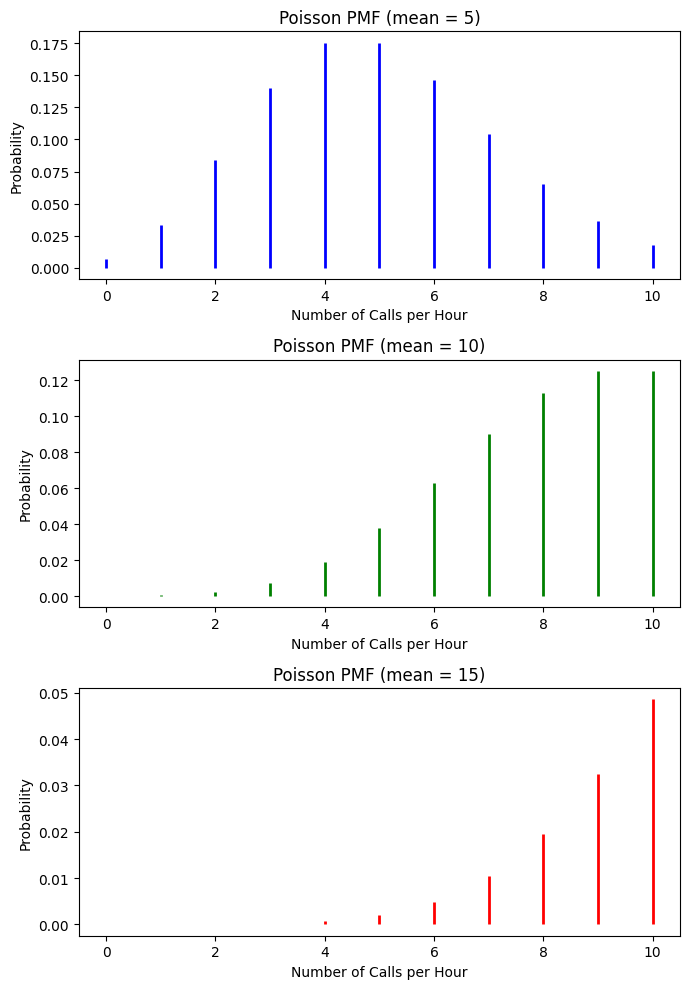

In [131]:


# we need to compute probability of [0 calls, 1 calls, 2 calls .. 10 calls]
k = np.arange(0, 11)

# Figure with 3 rows
fig, ax = plt.subplots(3, 1, figsize=(7, 10))

# ===== mean= 5 =====
y1 = st.poisson.pmf(k, 5)
ax[0].vlines(x=k, ymin=0, ymax=y1, color='b', lw=2)
ax[0].set_xlabel("Number of Calls per Hour")
ax[0].set_ylabel("Probability")
ax[0].set_title("Poisson PMF (mean = 5)")

for i in range(len(k)):
    print(f"mean=5, P(X={k[i]}) = {y1[i]:.5f}")

# ===== mean= 10 =====
y2 = st.poisson.pmf(k, 10)
ax[1].vlines(x=k, ymin=0, ymax=y2, color='g', lw=2)
ax[1].set_xlabel("Number of Calls per Hour")
ax[1].set_ylabel("Probability")
ax[1].set_title("Poisson PMF (mean = 10)")

# ===== mean= 15 =====
y3 = st.poisson.pmf(k, 15)
ax[2].vlines(x=k, ymin=0, ymax=y3, color='r', lw=2)
ax[2].set_xlabel("Number of Calls per Hour")
ax[2].set_ylabel("Probability")
ax[2].set_title("Poisson PMF (mean = 15)")


plt.tight_layout()
plt.show()


**Lab 07:**

 Normal Distribution: 
 
 i) To Show `unimodal and multimodal` density curves of normal distribution. <br>
 ii) To generate random sample with sample size 200, which follows a normal distribution with mean 100 and standard deviation 20. 
 
 iii) The distribution of diastolic blood pressure for men is normally distributed with a mean of about 80 and a standard deviation of 20. A histogram of the distribution of blood pressures for all mean displays a normal distribution with bell shape.
 <br>
 Probability Density Function (PDF):
$f(x \mid \mu, \sigma) = \frac{1}{\sigma \sqrt{2\pi}} , \exp\Bigg(-\frac{(x-\mu)^2}{2\sigma^2}\Bigg)$

 <br>

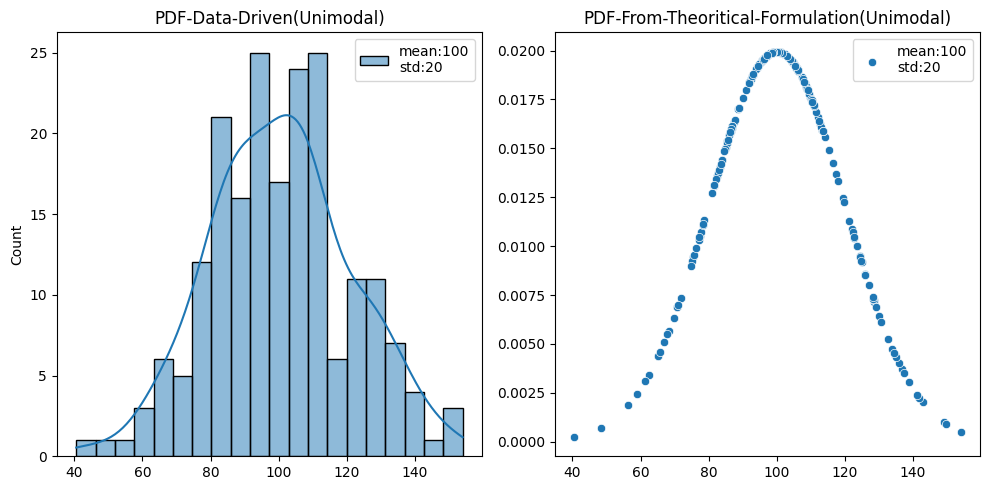

In [134]:


# ===== 1st: Random sample normal distribution ======
sample_size = 200
mean = 100 
std = 20 

x = np.random.normal(loc=mean,scale=std,size=sample_size)
y = st.norm.pdf(x,loc=mean,scale=std)

fig,ax = plt.subplots(1,2,figsize=(10,5))

# if sample_size increase then,we will get more smoother curve
# we made this by observing the data:
sns.histplot(x=x,bins=20,kde=True,ax=ax[0],label=f"mean:{mean}\nstd:{std}")
ax[0].set_title("PDF-Data-Driven(Unimodal)")
ax[0].legend()

# therotical PDF:
sns.scatterplot(x=x,y=y,ax=ax[1],label=f"mean:{mean}\nstd:{std}")
ax[1].set_title("PDF-From-Theoritical-Formulation(Unimodal)")
ax[1].legend()

plt.tight_layout()
plt.show()




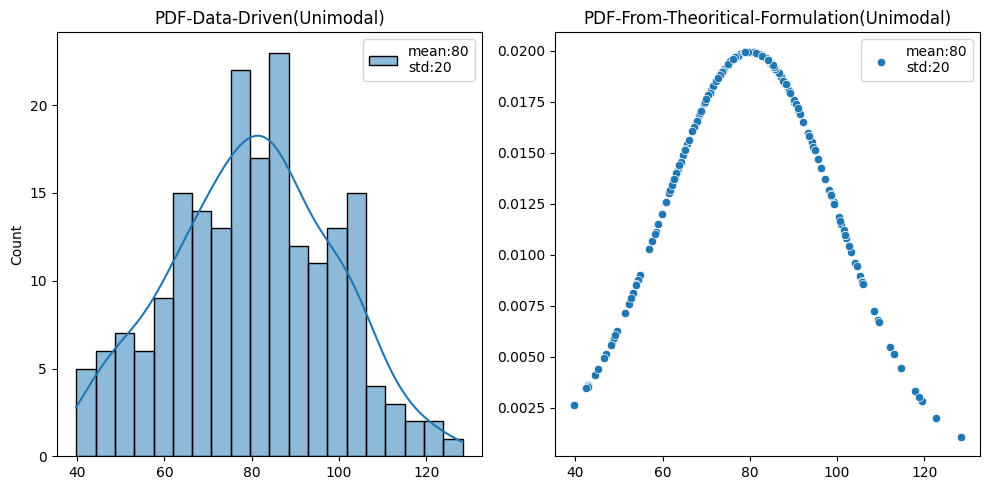

In [135]:

# ======= 2nd: histrogram diastolic blood pressure: ========
sample_size = 200
mean = 80 
std = 20 

x = np.random.normal(loc=mean,scale=std,size=sample_size)
y = st.norm.pdf(x,loc=mean,scale=std)

fig,ax = plt.subplots(1,2,figsize=(10,5))
sns.histplot(x=x,bins=20,kde=True,ax=ax[0],label=f"mean:{mean}\nstd:{std}")
ax[0].set_title("PDF-Data-Driven(Unimodal)")
ax[0].legend()

sns.scatterplot(x=x,y=y,ax=ax[1],label=f"mean:{mean}\nstd:{std}")
ax[1].set_title("PDF-From-Theoritical-Formulation(Unimodal)")
ax[1].legend()

plt.tight_layout()
plt.show()



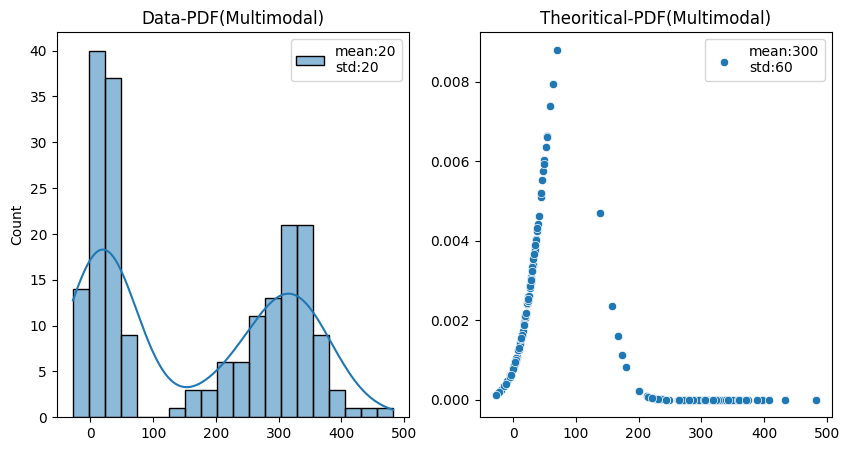

In [ ]:


# ======= Multimodal Density Curve ======
mean1 = 20 
mean2 = 300
std1 = 20
std2 = 60

avg_mean = int((80+100)/2)
avg_std = int((std1+std2)/2)

x1 = np.random.normal(loc=mean1,scale=std1,size=100)   
x2 = np.random.normal(loc=mean2,scale=std2,size=100) 

x_multi = np.concatenate([x1,x2])
y = st.norm.pdf(x=x_multi,loc=avg_mean,scale=avg_std)

fig,ax = plt.subplots(1,2,figsize=(10,5))
sns.histplot(x=x_multi,bins=20,kde=True,ax=ax[0],label=f"mean:{mean1}\nstd:{std1}")
ax[0].set_title("Data-PDF(Multimodal)")
ax[0].legend()

# theoritical: 
sns.scatterplot(x=x_multi,y=y,ax=ax[1],label=f"mean:{mean2}\nstd:{std2}")
ax[1].set_title("Theoritical-PDF(Multimodal)")
ax[1].legend()

plt.show()



<br>

**Lab 08:** <br>
Exponential Distribution: 

There were few waves in COVID-19 pandemic. Let a wave occurs every 100 days in Bangladesh, on average. After a wave occurs, find the probability using Exponential distribution that it will take more than 120 days for the next wave to occur. Simulate several Exponential distribution using rate parameters 0.5, 1.0, 2.0, and 4.0. 

<br>

In [138]:


# a wave occurs every 100 days (on average)
mean = 100 
x = 80

# rate_parameter=lamda
lamda = 1/mean 
print("rate: ",lamda)

next_wave =  np.exp(-(lamda*x))

# there is 30% of probability that next wave will come in next: 120 days 
print(f"P(X>={x}): {next_wave}")


rate:  0.01
P(X>=80): 0.44932896411722156


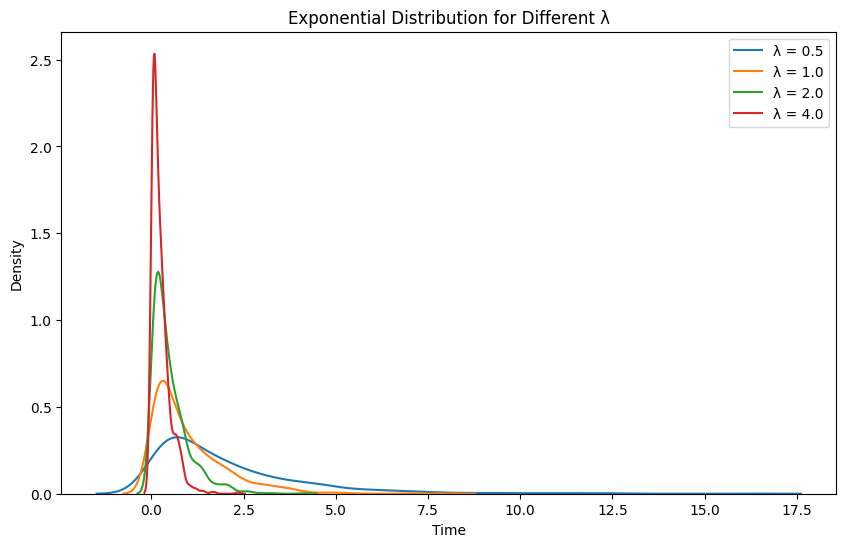

In [ ]:

# **if rate parameter incrase then mean will dease: next wave occur very shortly**
sample_size = 1000
rate_parameters = [0.5, 1.0, 2.0, 4.0]

plt.figure(figsize=(10,6))

for lam in rate_parameters:
    data = np.random.exponential(scale=1/lam, size=sample_size)
    sns.kdeplot(data, label=f"λ = {lam}")

plt.title("Exponential Distribution for Different λ")
plt.xlabel("Time")
plt.ylabel("Density")
plt.legend()
""" 
Observation:
lamda high-> event occur frequently that's why watting time low.
"""
plt.show()



<br>

**Lab 09:** <br>
Empirical Input Modeling: Given a raw dataset of customer arrival times at a call center, fit the data to theoretical distributions (e.g., Normal, Weibull, or Lognormal) using Maximum Likelihood Estimation (MLE). Validate the fit with Q-Q plots.

<br>

In [143]:

arrival_times = [2.1, 3.5, 4.2, 5.1, 2.8,6.0, 3.9, 4.8, 5.7, 2.9,3.3, 4.4,
                 5.0, 6.2, 3.7,4.1, 5.3, 6.8, 2.6, 4.7]
arrival_times


[2.1,
 3.5,
 4.2,
 5.1,
 2.8,
 6.0,
 3.9,
 4.8,
 5.7,
 2.9,
 3.3,
 4.4,
 5.0,
 6.2,
 3.7,
 4.1,
 5.3,
 6.8,
 2.6,
 4.7]

In [147]:

# parameter estimation: it uses the MLE equation:
# ====== fit our data into Normal, weibull and lognormal ======
data = np.array(arrival_times)

# Normal
mu, sigma = st.norm.fit(data)

# Weibull
shape_w, loc_w, scale_w = st.weibull_min.fit(data)

# Lognormal
shape_l, loc_l, scale_l = st.lognorm.fit(data)

print("Normal:")
print(mu, sigma)

print("\nWeibull:")
print(shape_w, scale_w)

print("\nLognormal:")
print(shape_l, scale_l)

Normal:
4.3549999999999995 1.2519884184767844

Weibull:
2.5343005528872857 3.2948909797551784

Lognormal:
0.06147520496677766 20.337685380401425


---


### 1. Normal Distribution

**PDF:**
$f(x;\mu,\sigma)=\frac{1}{\sigma\sqrt{2\pi}}\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$

**Likelihood:**
$L(\mu,\sigma)=\prod_{i=1}^{n}\frac{1}{\sigma\sqrt{2\pi}}\exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)$

**Log-Likelihood:**
$\log L(\mu,\sigma)=-n\log(\sigma)-\frac{n}{2}\log(2\pi)-\frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2$

**MLE Objective:**
$(\hat{\mu},\hat{\sigma})=\arg\max_{\mu,\sigma}\log L(\mu,\sigma)$

**MLE Estimates:**
$\hat{\mu}=\frac{1}{n}\sum_{i=1}^{n}x_i$

$\hat{\sigma}^2=\frac{1}{n}\sum_{i=1}^{n}(x_i-\hat{\mu})^2$

---

### 2. Weibull Distribution

Parameters:

* $k$ = shape
* $\lambda$ = scale

**PDF:**
$f(x;k,\lambda)=\frac{k}{\lambda}\left(\frac{x}{\lambda}\right)^{k-1}\exp\left(-\left(\frac{x}{\lambda}\right)^k\right)$

**Likelihood:**
$L(k,\lambda)=\prod_{i=1}^{n}\frac{k}{\lambda}\left(\frac{x_i}{\lambda}\right)^{k-1}\exp\left(-\left(\frac{x_i}{\lambda}\right)^k\right)$

**Log-Likelihood:**
$\log L(k,\lambda)=n\log k-nk\log\lambda+(k-1)\sum_{i=1}^{n}\log x_i-\sum_{i=1}^{n}\left(\frac{x_i}{\lambda}\right)^k$

**MLE Objective:**
$(\hat{k},\hat{\lambda})=\arg\max_{k,\lambda}\log L(k,\lambda)$

**MLE Equations:**
$\frac{\sum_{i=1}^{n}x_i^k\ln(x_i)}{\sum_{i=1}^{n}x_i^k}-\frac{1}{k}=\frac{1}{n}\sum_{i=1}^{n}\ln(x_i)$

$\hat{\lambda}=\left(\frac{1}{n}\sum_{i=1}^{n}x_i^k\right)^{1/k}$

**Note:**
$k$ has no closed-form MLE solution and is usually obtained numerically.

---

### 3. Lognormal Distribution

Parameters:

* $\mu$
* $\sigma$

**PDF:**
$f(x;\mu,\sigma)=\frac{1}{x\sigma\sqrt{2\pi}}\exp\left(-\frac{(\ln x-\mu)^2}{2\sigma^2}\right)$

**Likelihood:**
$L(\mu,\sigma)=\prod_{i=1}^{n}\frac{1}{x_i\sigma\sqrt{2\pi}}\exp\left(-\frac{(\ln x_i-\mu)^2}{2\sigma^2}\right)$

**Log-Likelihood:**
$\log L(\mu,\sigma)=-n\log\sigma-\frac{n}{2}\log(2\pi)-\sum_{i=1}^{n}\log x_i-\frac{1}{2\sigma^2}\sum_{i=1}^{n}(\ln x_i-\mu)^2$

**MLE Objective:**
$(\hat{\mu},\hat{\sigma})=\arg\max_{\mu,\sigma}\log L(\mu,\sigma)$

**MLE Estimates:**
$\hat{\mu}=\frac{1}{n}\sum_{i=1}^{n}\ln(x_i)$

$\hat{\sigma}^2=\frac{1}{n}\sum_{i=1}^{n}(\ln(x_i)-\hat{\mu})^2$

---

### General MLE Formula

**Likelihood Function:**
$L(\theta)=\prod_{i=1}^{n}f(x_i|\theta)$

**Log-Likelihood Function:**
$\log L(\theta)=\sum_{i=1}^{n}\log f(x_i|\theta)$

**MLE Estimator:**
$\hat{\theta}=\arg\max_{\theta}L(\theta)$

or equivalently

$\hat{\theta}=\arg\max_{\theta}\log L(\theta)$

---

In [146]:

# Log Likelihood calculation:
ll_normal = np.sum(st.norm.logpdf(data, mu, sigma))
ll_weibull = np.sum(st.weibull_min.logpdf(data,shape_w,loc_w,scale_w))
ll_lognormal = np.sum(st.lognorm.logpdf(data,shape_l,loc_l,scale_l))

print(ll_normal)
print(ll_weibull)
print(ll_lognormal)

-32.873431108437806
-32.48463966255815
-32.84585528344754


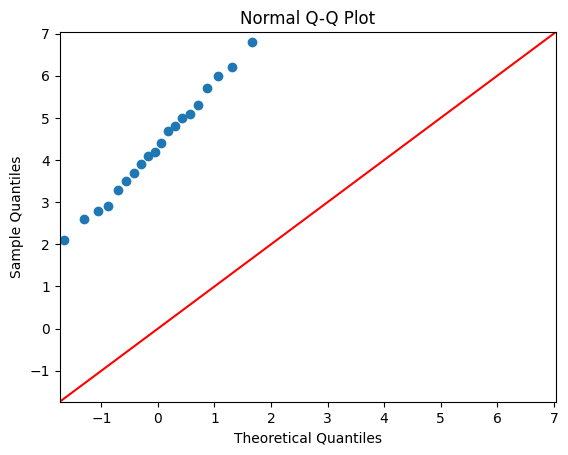

In [150]:

import statsmodels.api as sm
sm.qqplot(data,line='45')
plt.title("Normal Q-Q Plot")
plt.show()


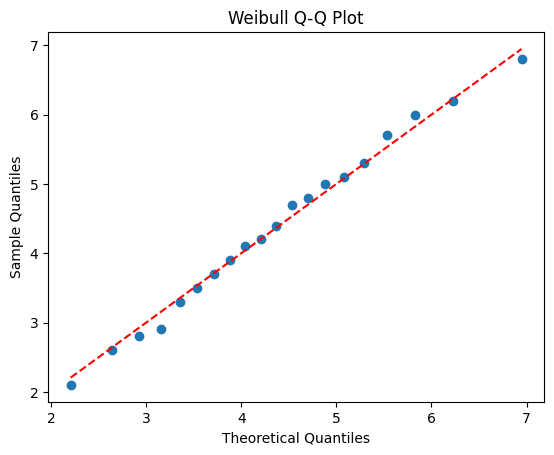

In [ ]:

from scipy import stats

n = len(data)
p = (np.arange(1, n + 1) - 0.5) / n

# ppf = inverse of cdf 
theoretical = stats.weibull_min.ppf(
    p,
    shape_w,
    loc_w,
    scale_w
)

sample = np.sort(data)
plt.scatter(theoretical, sample)

plt.plot(
    [theoretical.min(), theoretical.max()],
    [theoretical.min(), theoretical.max()],
    'r--'
)

plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.title("Weibull Q-Q Plot")

plt.show()

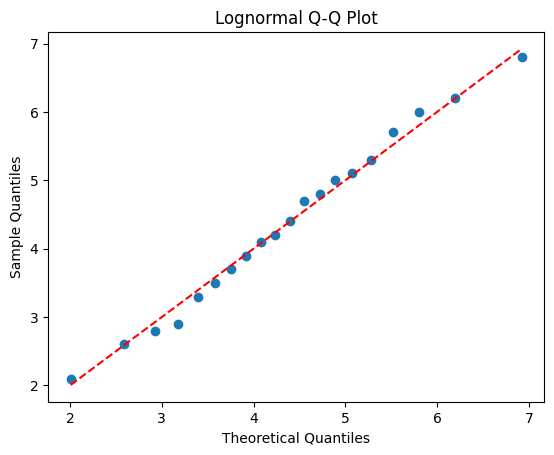

In [153]:
theoretical = st.lognorm.ppf(
    p,
    shape_l,
    loc_l,
    scale_l
)

sample = np.sort(data)

plt.scatter(theoretical, sample)

plt.plot(
    [theoretical.min(), theoretical.max()],
    [theoretical.min(), theoretical.max()],
    'r--'
)

plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.title("Lognormal Q-Q Plot")

plt.show()

<br>

**Lab 10:**
Machine Breakdown and Maintenance:

Simulate a manufacturing workshop containing 5 identical machines. The time between breakdowns is exponentially distributed, and repair times follow a Weibull distribution. Calculate machine downtime and overall system throughput.

<br>

downtime: 
* $(T_b)$ = Time between breakdowns
* $(\lambda)$ = Breakdown rate

PDF:
$f(t)=\lambda e^{-\lambda t}$

Repair time: weibull distribution:
* (k) = Shape parameter
* $(\lambda_w)$ = Scale parameter

PDF:

$f(t)=
\frac{k}{\lambda_w}
\left(\frac{t}{\lambda_w}\right)^{k-1}
e^{-(t/\lambda_w)^k}$

Availability:
$A=
\frac{\text{Operating Time}}
{\text{Operating Time + Downtime}}$


<br>


In [141]:

# mean = 1/lamda = 1/0.005 = 30 
num_machines = 5
breakdown_rate = 0.05

weibull_shape = 2
weibull_scale = 3
simulation_time = 100

# breakdowns time:(exponential distribution)
breakdowns = np.random.exponential(scale=1/breakdown_rate,size=20)

# Generate repair times: (weibull distribution:)
repairs = np.random.weibull(weibull_shape,size=20) * weibull_scale

# downtime:
total_downtime = repairs.sum()

# availbality: (ON)
availability = (simulation_time - total_downtime) / simulation_time



print("Total Downtime:", total_downtime)
print("Availability:", availability)



# througput calculation:
machine_output = 10

ideal_throughput = num_machines * machine_output
actual_throughput = ideal_throughput * availability
print("Actual Throughput:", actual_throughput)




Total Downtime: 58.63356362988013
Availability: 0.4136643637011987
Actual Throughput: 20.683218185059935


<br>

**Lab 11:** 

Linear Congruential Generator (LCG): LCG is considered one of the basic yet best methods to generate Pseudo-Random Numbers. Write a program which generates the random number using the LCG.

<br>

In [118]:

def lcg(seed, a, c, m, n):
    numbers = []
    current_x = seed
    
    print(f"Starting LCG with Seed={seed}, a={a}, c={c}, m={m}\n")
    print(f"{'n':<5} | {'Calculation':<25} | {'X_{n+1}'}")
    print("-" * 45)
    
    for i in range(n):
        # LCG Formula: X_{n+1} = (a*X_n + c) % m
        next_x = (a * current_x + c) % m
        calc_str = f"({a} * {current_x} + {c}) % {m}"
        print(f"{i+1:<5} | {calc_str:<25} | {next_x}")
        numbers.append(next_x)
        current_x = next_x 
    return numbers


# Seed
X0 = 27   
# Multiplier   
A = 17   
# Increment   
C = 43   
# Modulus    
M = 100   
# total number of random number    
count = 10  

# n = ( seed*A + C)%M
random_numbers = lcg(X0, A, C, M, count)
print("\nGenerated Random Numbers:", random_numbers)


Starting LCG with Seed=27, a=17, c=43, m=100

n     | Calculation               | X_{n+1}
---------------------------------------------
1     | (17 * 27 + 43) % 100      | 2
2     | (17 * 2 + 43) % 100       | 77
3     | (17 * 77 + 43) % 100      | 52
4     | (17 * 52 + 43) % 100      | 27
5     | (17 * 27 + 43) % 100      | 2
6     | (17 * 2 + 43) % 100       | 77
7     | (17 * 77 + 43) % 100      | 52
8     | (17 * 52 + 43) % 100      | 27
9     | (17 * 27 + 43) % 100      | 2
10    | (17 * 2 + 43) % 100       | 77

Generated Random Numbers: [2, 77, 52, 27, 2, 77, 52, 27, 2, 77]


<br>

**Lab 12:** <br>
Random variates using the inverse transform function: 
There are several general approaches to generating univariate Random Variable from the distribution function. Write a program which generates the desired number of random variates using the inverse transform function.

<br>

In [5]:

# Let's generate univariate random varibale from exponential distribution:
def generate_exponential_varitaes(n,beta):
    u = np.random.uniform(low=0,high=1,size=n)
    x = -beta * np.log(1-u)
    return x 

generate_exponential_varitaes(10,2.0)

array([0.85379528, 0.2976914 , 1.84243562, 0.37744961, 0.46993191,
       6.18687279, 1.01291077, 8.95820404, 0.61622658, 4.24676101])

<br>

**Lab 13:**

Generate 5,000 exponentially distributed random numbers using the Inverse Transform technique. Plot a histogram of the resulting numbers and overlay the theoretical exponential probability density function(as we are making random variate from exponential distribution then we will use exponential probability density function pdf)

<br>

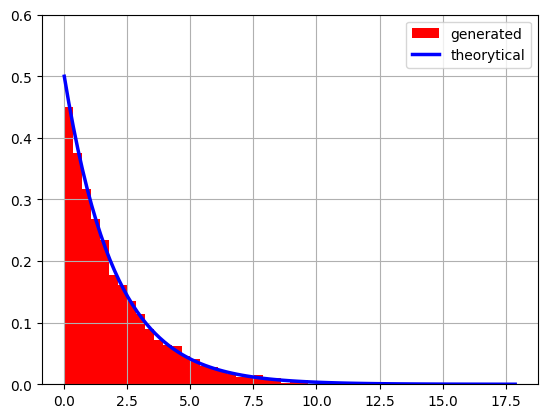

In [47]:

n = 5000
beta = 2.0

data = generate_exponential_varitaes(n,beta)


fig,ax = plt.subplots()

# make history of generate random variates:
ax.hist(x=data,bins=50,color='red',density=True,label="generated")

# Theoritical pdf:
x = np.linspace(start=0,stop=max(data),num=100)
theory_pdf = 1/beta  * np.exp(-x/beta)

ax.plot(x,theory_pdf,color='blue',lw=2.5,alpha=1,label="theorytical")

plt.legend()
plt.grid()
plt.ylim(0,0.6)
plt.show()




<br>

**Lab 14:** <br>
Debugging and Traceability (Verification): Write a trace program to step through a discrete-event model and log system states, ensuring it adheres exactly to the logical model rules.

<br>

<br>

**Lab 15:**
Confidence Interval Estimation: Calculate a 95% confidence interval for the mean system response (e.g., average waiting time) by running multiple independent replications of a simulation model.

<br>

In [74]:

sim_res = [5.2,5.8,6.1,4.9,5.5,5.7,5.0,5.6]
confidence_label = 0.95
n = len(sim_res)

mean = np.mean(sim_res)
st_error = st.sem(sim_res)

# small data using t distribution:
conf_interval = st.t.interval(confidence_label,n-1,loc=mean,scale=st_error)

print(f"confidence interval at {confidence_label} confidence level: {conf_interval}")



confidence interval at 0.95 confidence level: (np.float64(5.129576342365309), np.float64(5.820423657634691))


<br>
**Lab 16:** <br>
Steady-State Analysis: Analyze the warm-up period of a non-terminating simulation (like a continuous manufacturing line) and calculate the steady-state mean time.
<br>


steady mean data: 55.62977257106339



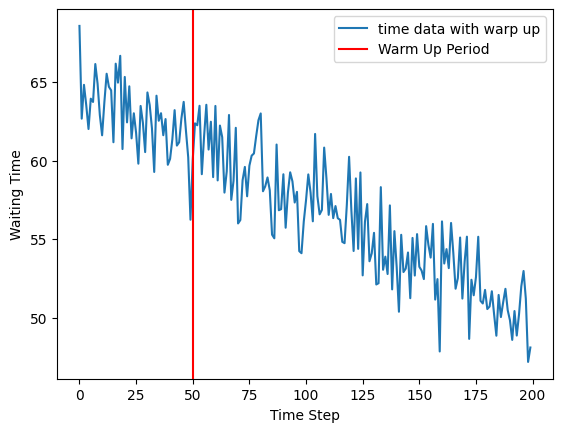

In [70]:


warm_up_period = 50 
time_step = 200
trend = np.linspace(start=25,stop=10,num=time_step)
noise  = np.random.normal(loc=40,scale=2,size=time_step)
simulation_time_data = trend + noise 

steady_state_time = simulation_time_data[warm_up_period:]
steady_mean = np.mean(steady_state_time)


print()
print("steady mean data: {}".format(steady_mean))
print()

# plot:
plt.plot(simulation_time_data,label="time data with warp up")
plt.axvline(x=warm_up_period,color="r",label="Warm Up Period")
plt.xlabel("Time Step")
plt.ylabel("Waiting Time")

plt.legend()
plt.show()


<br>

**Lab 17:** <br>
Bank ATM System Simulation: Model an ATM vestibule where customers arrive at random, use one of several machines, and leave. Calculate the maximum queue lengths.

<br>

In [ ]:
import random 

num_of_atms = 2 

# Binomial dist:
# no. of cus E[x] = n(minutes) * p 
customer_arrival_rate_per = 0.5
service_time = 5 
simulation_time = 100

queue_length = 0 
max_queue = 0 
atm_busy = [0]*num_of_atms

for minute in range(simulation_time):
    
    # customer arrival 
    if random.random()<customer_arrival_rate_per:
        queue_length +=1 
    
    # is atm is free or not:
    for i in range(num_of_atms):
        if atm_busy[i] <= minute  and queue_length>0:
            queue_length -=1 
            atm_busy[i] = minute + service_time
    
    if queue_length>max_queue:
        max_queue =  queue_length

print("Max Queue length: {}".format(max_queue))


Max Queue length: 11


<br>

**Lab 18:** 

Fast-Food Drive-Thru Model: Simulate a drive-thru process (order, pay, pick up) to identify the system's operational bottlenecks. 

<br>

In [89]:

import random 

# simulation model output analysis:
order_time = 2 
pay_time = 1 
picktup_time = 2 

num_customers = 10 
order_avg = 0
payment_avg = 0 
pick_avg = 0
total_system_time = 0 

print(f"{'Customer':<10} | {'Order':<6} | {'Pay':<6} | {'Pickup':<6} | {'Total':<6}")
print("*"*50)

for i in range(1, num_customers+1):
    o = random.uniform(order_time-0.5,order_time+0.5)
    p = random.uniform(pay_time-0.2,pay_time+0.2)
    u = random.uniform(picktup_time-0.5,picktup_time+0.5)
    
    total = o + p + u 
    order_avg +=o 
    payment_avg += p
    pick_avg += u 
    total_system_time += total
    
    print(f"{i:<10} | {o:<6.1f} | {p:<6.1f} | {u:<6.1f} | {total:<6.1f}")
    
print()
print(f"Need: {order_time:<5} order avg: {order_avg/num_customers}")
print(f"Need: {pay_time:<5} payment avg: {payment_avg/num_customers}")
print(f"Need: {picktup_time:<5} pick_avg: {pick_avg/num_customers}")
print(f"Need: {order_time+pay_time+picktup_time:<5} Agerage time: {total_system_time/num_customers}")



Customer   | Order  | Pay    | Pickup | Total 
**************************************************
1          | 1.8    | 1.0    | 2.1    | 4.9   
2          | 1.5    | 0.8    | 1.6    | 3.9   
3          | 2.4    | 1.1    | 1.8    | 5.2   
4          | 2.3    | 1.0    | 2.0    | 5.2   
5          | 2.4    | 1.1    | 2.4    | 6.0   
6          | 2.3    | 1.1    | 2.4    | 5.9   
7          | 2.5    | 0.9    | 2.2    | 5.7   
8          | 2.0    | 1.0    | 1.6    | 4.6   
9          | 2.4    | 1.1    | 1.6    | 5.2   
10         | 2.0    | 1.1    | 1.9    | 5.1   

Need: 2     order avg: 2.166301236554024
Need: 1     payment avg: 1.0334577261739737
Need: 2     pick_avg: 1.961697129115119
Need: 5     Agerage time: 5.1614560918431165


<br>

**Lab 19:**
Emergency Room (ER) Patient Flow: Simulate the triage, treatment, and discharge of patients in an ER to minimize waiting times and allocate resources.

<br>

In [90]:


import random 

# simulation model output analysis:
triage_time = 2 
treatment_time = 1 
discharge_time = 2 

num_customers = 10 
order_avg = 0
payment_avg = 0 
pick_avg = 0
total_system_time = 0 

print(f"{'Customer':<10} | {'Order':<6} | {'Pay':<6} | {'Pickup':<6} | {'Total':<6}")
print("*"*50)

for i in range(1, num_customers+1):
    o = random.uniform(triage_time-0.5,triage_time+0.5)
    p = random.uniform(treatment_time-0.2,treatment_time+0.2)
    u = random.uniform(discharge_time-0.5,discharge_time+0.5)
    
    total = o + p + u 
    order_avg +=o 
    payment_avg += p
    pick_avg += u 
    total_system_time += total
    
    print(f"{i:<10} | {o:<6.1f} | {p:<6.1f} | {u:<6.1f} | {total:<6.1f}")
    
print()
print(f"Need: {triage_time:<5} order avg: {order_avg/num_customers}")
print(f"Need: {treatment_time:<5} payment avg: {payment_avg/num_customers}")
print(f"Need: {discharge_time:<5} pick_avg: {pick_avg/num_customers}")
print(f"Need: {triage_time+treatment_time+discharge_time:<5} Agerage time: {total_system_time/num_customers}")




Customer   | Order  | Pay    | Pickup | Total 
**************************************************
1          | 2.2    | 1.1    | 2.5    | 5.7   
2          | 2.2    | 1.2    | 1.9    | 5.3   
3          | 1.8    | 1.0    | 2.2    | 5.0   
4          | 1.8    | 1.0    | 2.5    | 5.3   
5          | 2.0    | 0.8    | 2.4    | 5.3   
6          | 2.0    | 0.9    | 1.7    | 4.6   
7          | 2.3    | 1.2    | 1.7    | 5.2   
8          | 2.2    | 0.8    | 1.6    | 4.6   
9          | 1.9    | 1.0    | 1.5    | 4.3   
10         | 2.3    | 1.0    | 2.1    | 5.3   

Need: 2     order avg: 2.0589596694431345
Need: 1     payment avg: 0.9997018755828989
Need: 2     pick_avg: 2.0003998995423102
Need: 5     Agerage time: 5.059061444568345


<br>

**Lab 20:**
Statistical Output Analysis and Precision Estimation for a Drive-Thru Pharmacy Simulation: <br>
This lab problem evaluates customer flow at an automated drive-thru pharmacy kiosk operating as a terminating simulation system until 50 cars are served. Students are provided with average customer waiting times across five independent replication runs (3.2, 4.3, 5.1, 4.2, and 4.6 minutes) and must apply output data analysis techniques to evaluate the system. The tasks require calculating the overall point estimate (sample mean), computing the sample variance and standard error to measure stochastic variability, and constructing a 95% confidence interval using a Student's t-distribution. Finally, students must determine the total number of simulation replications required to achieve a desired half-width precision of no more than 0.5 minutes, demonstrating how statistical confidence dictates simulation run length.

<br>

In [95]:


sim_res = [3.2,4.3,5.1,4.2,4.6]
confidence_level = 0.95

mean = np.mean(sim_res)
std_error = st.sem(sim_res)

intervals = st.t.interval(confidence_level,len(sim_res)-1,loc=mean,scale=std_error)
print("Point Estimate: ",mean) 
intervals 

Point Estimate:  4.279999999999999


(np.float64(3.4134999948528453), np.float64(5.1465000051471534))